In [4]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

(64, 1000, 111)


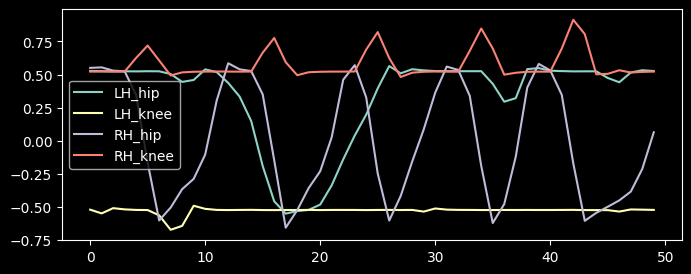

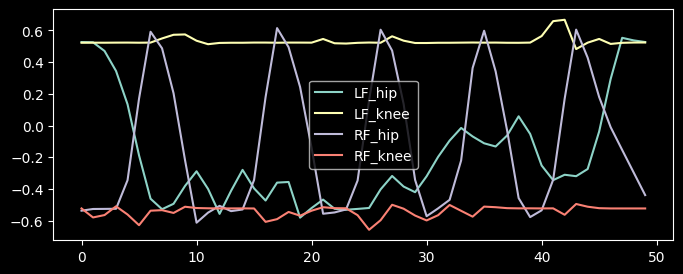

In [11]:
state_path = 'Ant_states.pt'
action_path = 'Ant_actions.pt'

# convert to numpy arrays
states = torch.load(state_path, map_location=torch.device('cpu'), weights_only=True).numpy()
actions = torch.load(action_path, map_location=torch.device('cpu'), weights_only=True).numpy()

print(states.shape)

plt.figure(figsize=(8, 3))
plt.plot(states[0, 400:450, 9], label='LH_hip')
plt.plot(states[0, 400:450, 10], label='LH_knee')
plt.plot(states[0, 400:450, 11], label='RH_hip')
plt.plot(states[0, 400:450, 12], label='RH_knee')
plt.legend()

plt.figure(figsize=(8, 3))
plt.plot(states[0, 400:450, 5], label='LF_hip')
plt.plot(states[0, 400:450, 6], label='LF_knee')
plt.plot(states[0, 400:450, 7], label='RF_hip')
plt.plot(states[0, 400:450, 8], label='RF_knee')
plt.legend()

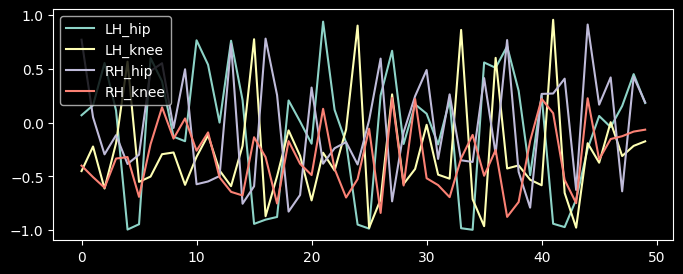

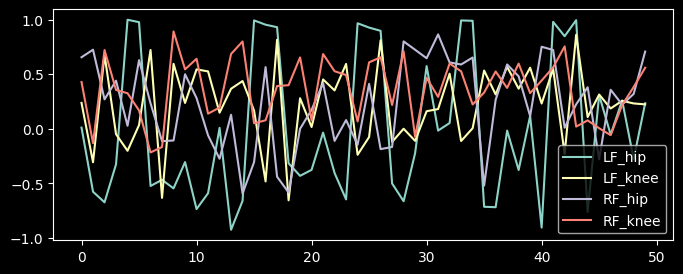

In [12]:
plt.figure(figsize=(8, 3))
plt.plot(actions[0, 400:450, 0], label='LH_hip')
plt.plot(actions[0, 400:450, 1], label='LH_knee')
plt.plot(actions[0, 400:450, 2], label='RH_hip')
plt.plot(actions[0, 400:450, 3], label='RH_knee')
plt.legend()

plt.figure(figsize=(8, 3))
plt.plot(actions[0, 400:450, 4], label='LF_hip')
plt.plot(actions[0, 400:450, 5], label='LF_knee')
plt.plot(actions[0, 400:450, 6], label='RF_hip')
plt.plot(actions[0, 400:450, 7], label='RF_knee')
plt.legend()

(50, 8)


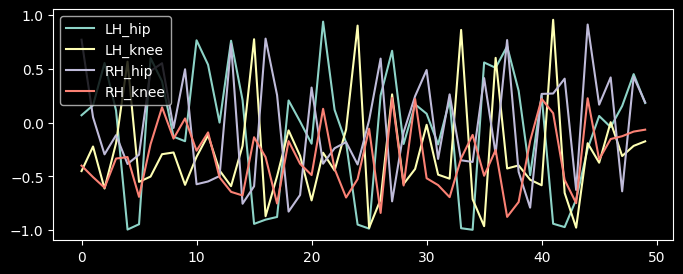

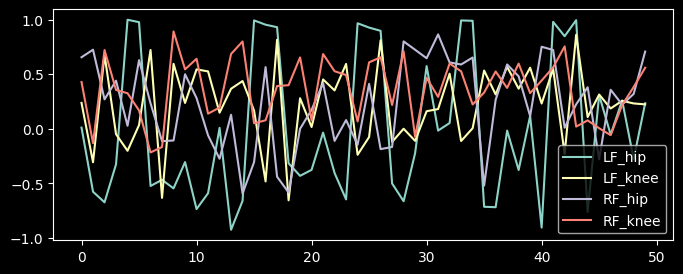

In [19]:
def make_loopable_cycle(data, window_length=200, polyorder=3, overlap_len=50):
    """
    :param data: (T, D) gait sequence (T time steps, D dimensions)
    :param window_length: smoothing window length (should be odd and > polyorder)
    :param polyorder: smoothing polynomial degree
    :param overlap_len: how many frames to overlap head-tail
    """
    assert len(data.shape) == 2  # (T, D)
    T, D = data.shape

    # Step 1: connect tail and head with some overlap
    head = data[:overlap_len]
    tail = data[-overlap_len:]
    extended = np.concatenate([tail, data, head], axis=0)  # shape: (T + 2 * overlap_len, D)

    # Step 2: smooth the extended trajectory
    smoothed = savgol_filter(extended, window_length=window_length, polyorder=polyorder, axis=0)

    # Step 3: trim back to original length, centered to avoid boundary artifacts
    start = overlap_len
    end = overlap_len + T
    loopable = smoothed[start:end]

    return loopable

action_choose = make_loopable_cycle(actions[0, 400:450, :], window_length=1, polyorder=0, overlap_len=3)
print(action_choose.shape)

plt.figure(figsize=(8, 3))
plt.plot(action_choose[:, 0], label='LH_hip')
plt.plot(action_choose[:, 1], label='LH_knee')
plt.plot(action_choose[:, 2], label='RH_hip')
plt.plot(action_choose[:, 3], label='RH_knee')
plt.legend()

plt.figure(figsize=(8, 3))
plt.plot(action_choose[:, 4], label='LF_hip')
plt.plot(action_choose[:, 5], label='LF_knee')
plt.plot(action_choose[:, 6], label='RF_hip')
plt.plot(action_choose[:, 7], label='RF_knee')
plt.legend()